In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel('dataset for data analytics.xlsx')

#Data exploration
# df.head()
# df.tail()
# df.info()
# df.describe()
# df.columns

#Listing the columns we are analyzing
num_cols = ['quantity', 'unit_price', 'total_price']

#Create a summary table for mean, median, and count
num_cols = ['Quantity', 'UnitPrice', 'TotalPrice']

summary_table = df[num_cols].agg(['mean', 'median', 'count'])


KeyError: "None of [Index(['quantity', 'unit_price', 'total_price'], dtype='str')] are in the [columns]"

In [4]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

# 1. Load fresh dataset
df = pd.read_excel("Dataset for Data Analytics.xlsx").drop_duplicates()

# 2. Text formatting
text_cols = ["OrderID", "CustomerID", "Product", "ShippingAddress", 
             "PaymentMethod", "OrderStatus", "TrackingNumber", 
             "CouponCode", "ReferralSource"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# 3. Clean Date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# 4. Clean Numeric Columns safely
for col in ["Quantity", "UnitPrice", "ItemsInCart"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").abs()

# Keep positive, non-null values
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# 5. Recalculate Total Price
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# 6. Drop missing essential records
df = df.dropna(subset=["OrderID", "CustomerID", "Date"])

# 7. Export Cleaned Dataset
df.to_excel("cleaned_dataset.xlsx", index=False, sheet_name="Cleaned Data")
print(f"Dataset successfully cleaned! Valid rows: {len(df)}")

Dataset successfully cleaned! Valid rows: 1200


C:\Users\USER PC\AppData\Local\Temp\ipykernel_15520\2822590890.py:5: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('Amazon Sale Report.csv')


   index             Order ID       Date                        Status  \
0      0  405-8078784-5731545  4/30/2022                     Cancelled   
1      1  171-9198151-1101146  4/30/2022  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  4/30/2022                       Shipped   
3      3  403-9615377-8133951  4/30/2022                     Cancelled   
4      4  407-1069790-7240320  4/30/2022                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... currency  Amount    ship-city   ship-state  \
0            Set  ...      INR

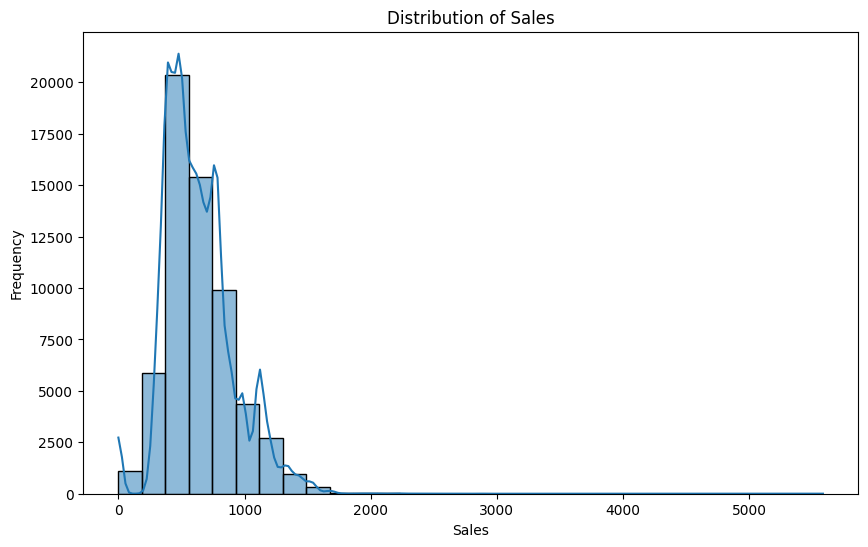

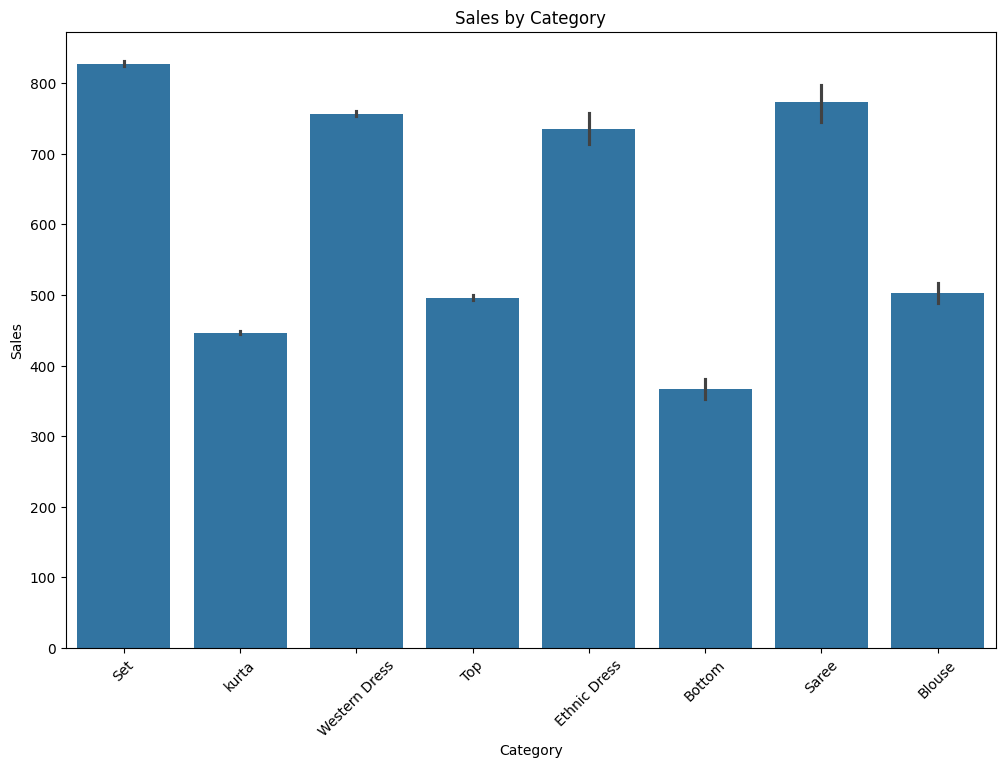

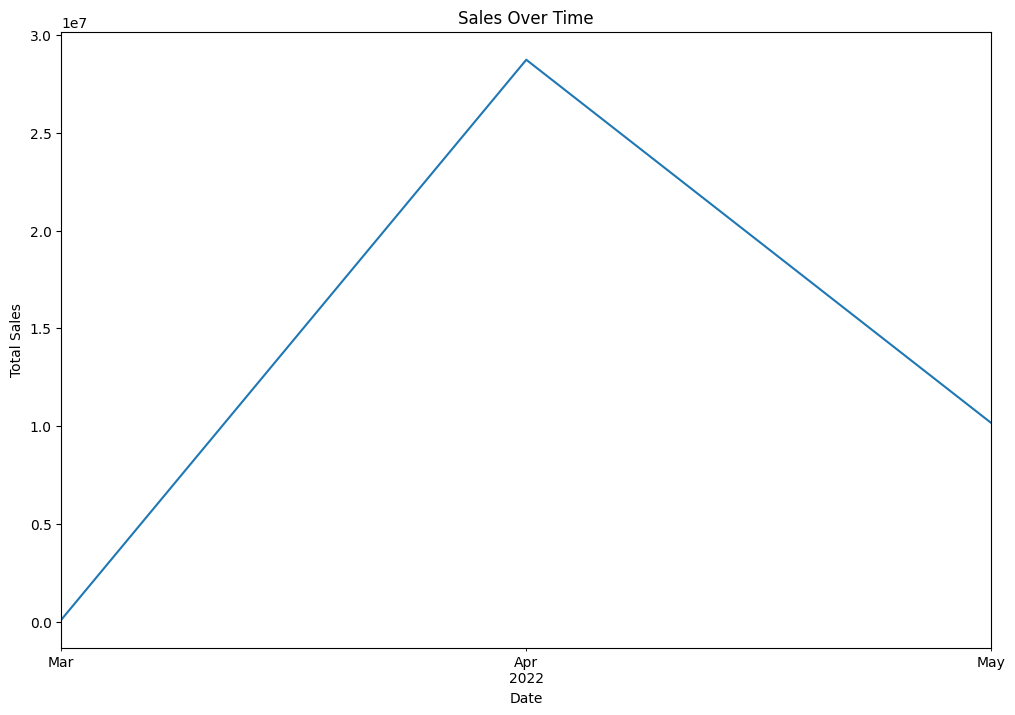

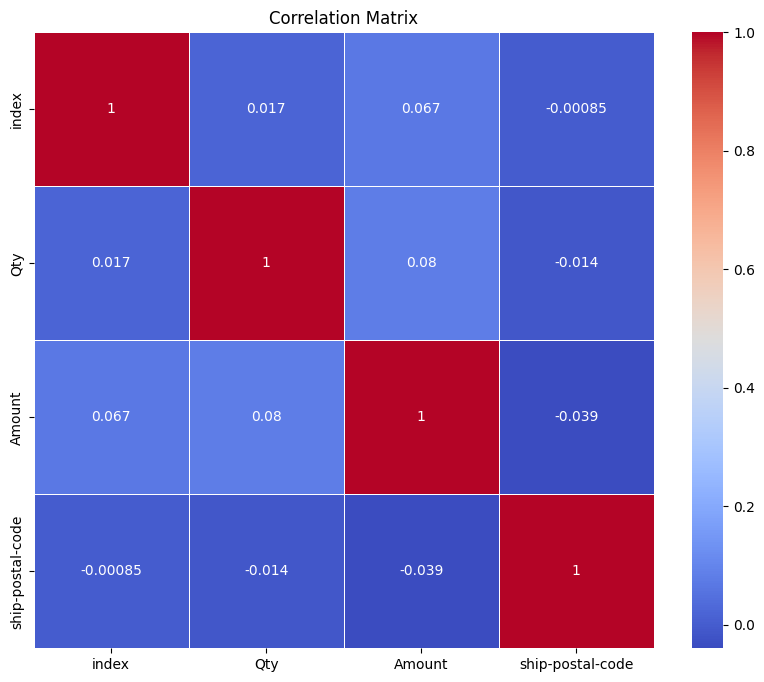

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data=pd.read_csv('Amazon Sale Report.csv')

# Display the first few rows of the dataset
print(data.head())

# Check for missing values
print(data.isnull().sum())
# Basic statistics of the dataset
print(data.describe())
print(data.info())

# Distribution of sales
plt.figure(figsize=(10,6))
sns.histplot(data['Amount'], bins=30, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# Sales by category
plt.figure(figsize=(12, 8))
sns.barplot(data=data, x='Category', y='Amount')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

# Sales over time
plt.figure(figsize=(12, 8))
data['Date']=pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data['Amount'].resample('ME').sum().plot()
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

# Correlation between sales and other numerical features
numerical_feature=data.select_dtypes(include=['float64', 'int64'])
correlation_matrix=numerical_feature.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# df.tail()
# df.head()
# df.info()
# df.describe
# load the dataset
df=pd.read_csv("Amazon Sale Report.csv")

# Total Revenue and Total Items Sold
print(f"total revenue: INR = {df['Amount'].sum():,.2f}")
print(f"total Item Sold: = {df['Qty'].sum():,}")
  
# if 'currency' in df.columns:
#     currency_used = df['currency'].dropna().unique()[0]
# else:
#     currency_used = "INR"
    
# Order Status Breakdown
print("\nOrder Status Breakdown:")
print(df['Status'].value_counts().to_string())

# Most Popular Size
print(f"\nMost Popular Size: {df.groupby('Size')['Qty'].sum().idxmax()}")
    
    
    

        






total revenue: INR = 38,992,282.16
total Item Sold: = 58,772

Order Status Breakdown:
Status
Shipped                          39054
Shipped - Delivered to Buyer     15593
Cancelled                         9177
Shipped - Returned to Seller      1147
Shipped - Picked Up                  7
Shipped - Rejected by Buyer          6
Shipped - Returning to Seller        6
Pending                              5
Shipped - Lost in Transit            3
Shipped - Out for Delivery           1

Most Popular Size: M


C:\Users\USER PC\AppData\Local\Temp\ipykernel_17372\1135501349.py:12: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("Amazon Sale Report.csv")


<Figure size 1400x600 with 0 Axes>

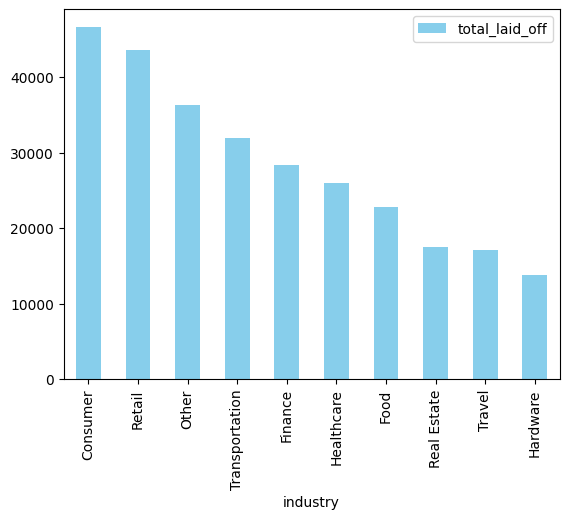

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df=pd.read_csv('layoffs.csv')
# df.tail()
# df.head()
# df.info()
# df.describe
# df.columns
df['date']=pd.to_datetime(df['date'])
df['year_month']=df['date'].dt.to_period('M')
df['year_month']

# monthly_data = df.groupby('year_month').size().reset_index(name='total_events')
# monthly_data['year_month'] = monthly_data['year_month'].astype(str)

# plt.figure(figsize=(12, 6))


# sns.barplot(data=monthly_data, x='year_month', y='total_events', palette='viridis')

# plt.title('Layoffs Per Month', fontsize=16, fontweight='bold')
# plt.xlabel('Month', fontsize=12)
# plt.ylabel('Number of Layoff Events', fontsize=12)
# plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()

# top t10 companies with most layoffs
# plt.figure(figsize=(14,6))
# top10 = df.groupby('company')['total_laid_off'].sum().reset_index().sort_values(by="total_laid_off", ascending=False).head(10)
# top10.plot(kind='bar',x='company',y='total_laid_off', color="skyblue")

# plt.show()

# top 10 industries with most layoffs

plt.figure(figsize=(14,6))
top10 = df.groupby('industry')['total_laid_off'].sum().reset_index().sort_values(by='total_laid_off', ascending=False).head(10)
top10.plot(kind='bar',x='industry',y='total_laid_off',color="skyblue")

plt.show()

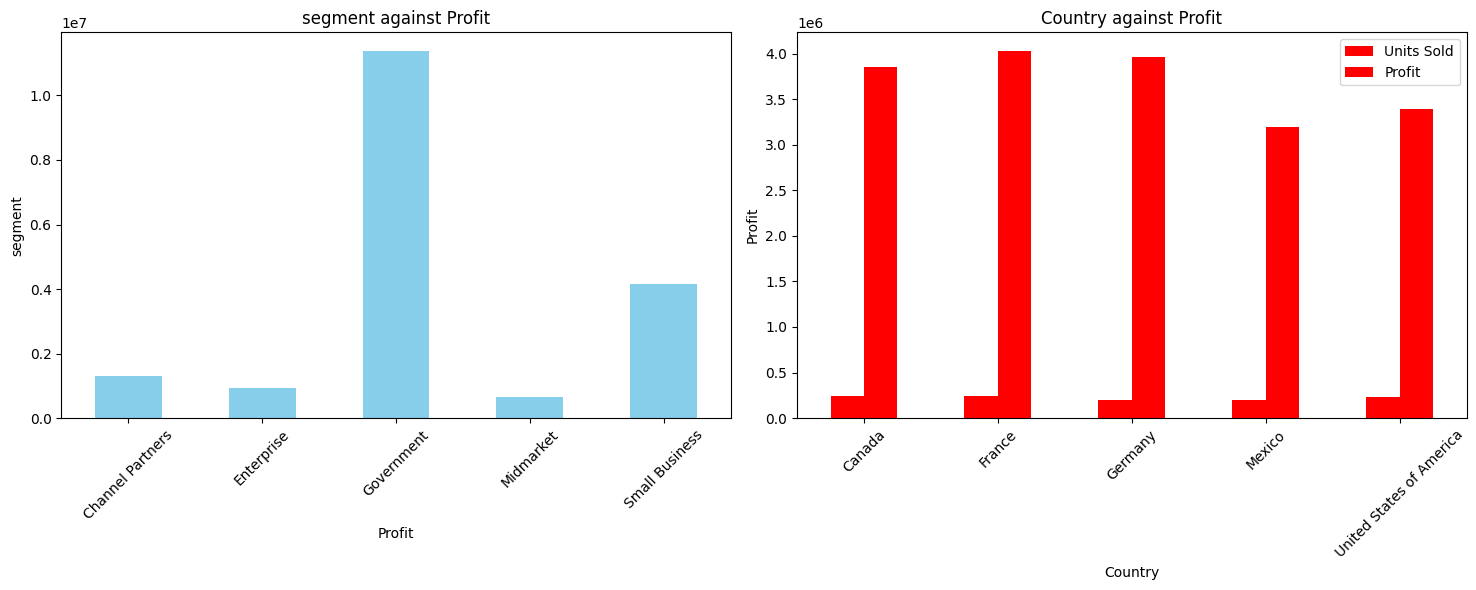

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
df=pd.read_csv("Financial_Sample.csv")
df.head(10)
df.columns=df.columns.str.strip()
#print(df['Profit'].to_string())
df['Profit']=df['Profit'].str.replace('$','')
df['Profit']=df['Profit'].str.replace(',','')
df['Profit']=df['Profit'].str.replace('(','')
df['Profit']=df['Profit'].str.replace(')','')
#print(df['Profit'].to_string())
df['Profit']=pd.to_numeric(df['Profit'],errors='coerce')
df['Profit'].sum()

segment_group=df.groupby('Segment')['Profit'].sum()
product_group =df.groupby('Product')['Profit'].sum()
country_data=df.groupby('Country')[['Units Sold','Profit']].sum()


fig,(ax1,ax2)=plt.subplots(1,2, figsize=(15,6))
segment_group.plot(kind='bar', color='skyblue',ax=ax1)
ax1.set_title('segment against Profit')
ax1.set_ylabel('segment')
ax1.set_xlabel('Profit')
ax1.tick_params(axis='x', rotation=45)
country_data.plot(kind='bar' ,color='red',ax=ax2)
ax2.set_title('Country against Profit')
ax2.set_ylabel('Profit')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()






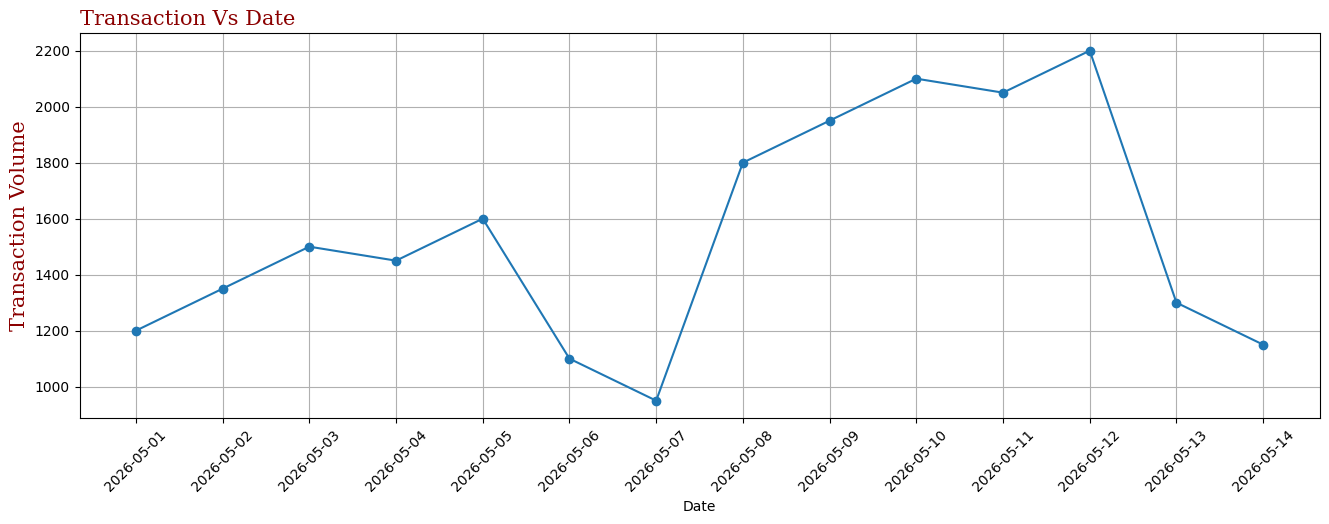

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data=pd.read_csv('matplotlib_practice_dataset.csv')
plt.figure(figsize=(16,5))
# plt.plot(data['Date'],data['Total_Transactions'],linestyle='--', color='red' ,label='Total Attempts')
# plt.plot(data['Date'],data['Successful_Payments'],linestyle='-',color='blue',label="successful")


x=data['Date']
y=data['Total_Transactions']
plt.plot(x,y, marker='o')
font1= {'family':'serif','color':'blue','size':20}
font2={'family':'serif','color':'darkred','size':15}
plt.xlabel('Date')
plt.ylabel('Transaction Volume',fontdict=font2)
plt.title("Transaction Vs Date",loc="left" ,fontdict=font2)
plt.xticks(rotation=45)
plt.grid()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

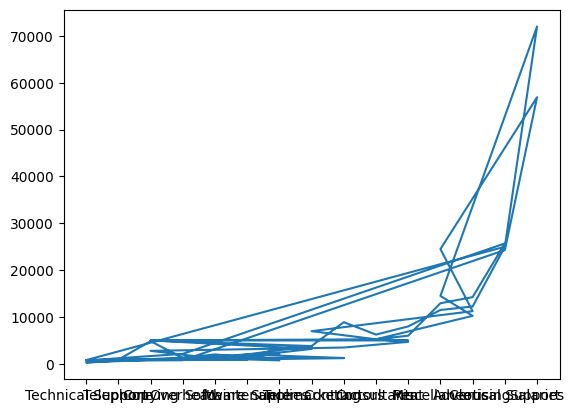

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
data=pd.read_csv("classwork.csv")
xplt= data["Category"]
yplt= data["January"]
plt.plot(xplt,yplt)
plt.show

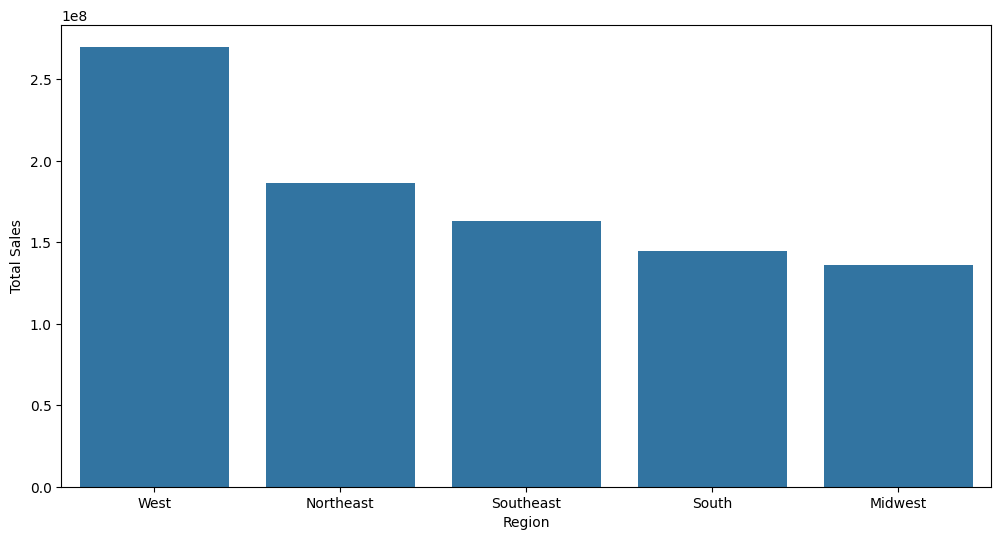

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

file_path = "Adidas US Sales Datasets.csv"

data = pd.read_csv(file_path, header=None)

data = data.drop([0,1,2,3])
data.columns = data.iloc[0]
data = data.drop(4).reset_index(drop=True)


def removedollar(x):
    if isinstance(x, str):
        x = x.replace('$', '').replace(',', '')
    return pd.to_numeric(x, errors='coerce')


def removepercentage(x):
    if isinstance(x, str):
        x = x.replace('%', '')
    return pd.to_numeric(x, errors='coerce') / 100


def removeunit(x):
    if isinstance(x, str):
        x = x.replace(',', '').replace(' units', '')
    return pd.to_numeric(x, errors='coerce')


data['Operating Profit'] = data['Operating Profit'].apply(removedollar)

data['Total Sales'] = data['Total Sales'].apply(removedollar)

data['Operating Margin']=data['Operating Margin'].apply(removepercentage)

data['Price per Unit']=data['Price per Unit'].apply(removedollar)

data['Units Sold']=data['Units Sold'].apply(removedollar)

data['Invoice Date']=pd.to_datetime(data['Invoice Date'], errors='coerce')

data=data.dropna(subset=['Retailer','Total Sales'])

data

#exploraton
# data.head()
# data.tail()
# data.info()
# data.describe()
# data.columns
# print(data['Operating Profit'])

plt.figure(figsize=(12,6))
regiosales=data.groupby('Region')['Total Sales'].sum().reset_index().sort_values(by='Total Sales')
sns.barplot(data=regionsales,x='Region',y='Total Sales')
plt.show()


In [ ]:
import pandas as pd
df=pd.read_csv("w3school.csv")
#x=df["Calories"].median()
#df.fillna({"Calories":x},inplace=True)
#print(x)
#print(df.to_string)
df["Date"]=pd.to_datetime(df["Date"],format="mixed")
df.dropna(subset=["Date"], inplace=True)


#df.loc[7, 'Duration'] = 45

#for x in df.index:
 #   if df.loc[x, "Duration"] > 40:
  #      df.loc[x, "Duration"] = 20
   
   
#for x in df.index:
      #if df.loc[x, "Duration"] > 20:
       #df.drop(x, inplace = True)
       
#df.duplicated()
#df.drop_duplicates(inplace=True)

df.corr()


,Duration,Date,Pulse,Maxpulse,Calories
Duration,1.000000,-0.139071,-0.000572,0.042271,-0.118819
Date,-0.139071,1.000000,-0.360587,-0.502902,-0.352105
Pulse,-0.000572,-0.360587,1.000000,0.269000,0.510361
Maxpulse,0.042271,-0.502902,0.269000,1.000000,0.352529
Calories,-0.118819,-0.352105,0.510361,0.352529,1.000000


In [ ]:
import pandas as pd
df=pd.read_csv("w3school.csv")
x=df["Calories"].median()
df.fillna({"Calories":x},inplace=True)
#print(x)
#print(df.to_string)
df["Date"]=pd.to_datetime(df["Date"],format="mixed")
df.dropna(subset=["Date"], inplace=True)
df


,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020-12-01,110,130,409.1
1,60,2020-12-02,117,145,479.0
2,60,2020-12-03,103,135,340.0
3,45,2020-12-04,109,175,282.4
4,45,2020-12-05,117,148,406.0
5,60,2020-12-06,102,127,300.0
6,60,2020-12-07,110,136,374.0
7,450,2020-12-08,104,134,253.3
8,30,2020-12-09,109,133,195.1
9,60,2020-12-10,98,124,269.0


In [ ]:
import pandas as pd
df=pd.read_csv("w3school.csv")
x=df["Calories"].median()
df.fillna({"Calories":x},inplace=True)
print(x)
#print(df.to_string)

291.2


In [ ]:
import pandas as pd
df=pd.read_csv("w3school.csv")
x=df["Calories"].mean()
df.fillna({"Calories":x},inplace=True)
#print(x)
print(df.to_string)

<bound method DataFrame.to_string of     Duration          Date  Pulse  Maxpulse  Calories
0         60  '2020/12/01'    110       130    409.10
1         60  '2020/12/02'    117       145    479.00
2         60  '2020/12/03'    103       135    340.00
3         45  '2020/12/04'    109       175    282.40
4         45  '2020/12/05'    117       148    406.00
5         60  '2020/12/06'    102       127    300.00
6         60  '2020/12/07'    110       136    374.00
7        450  '2020/12/08'    104       134    253.30
8         30  '2020/12/09'    109       133    195.10
9         60  '2020/12/10'     98       124    269.00
10        60  '2020/12/11'    103       147    329.30
11        60  '2020/12/12'    100       120    250.70
12        60  '2020/12/12'    100       120    250.70
13        60  '2020/12/13'    106       128    345.30
14        60  '2020/12/14'    104       132    379.30
15        60  '2020/12/15'     98       123    275.00
16        60  '2020/12/16'     98       120  

In [ ]:
import pandas as pd
df=pd.read_csv("w3school.csv")
#new_df=df.dropna()
#print(new_df.to_string())
df.fillna(619,inplace=True)
df.fillna({"Calories":619}, inplace=True)
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0
5,60,'2020/12/06',102,127,300.0
6,60,'2020/12/07',110,136,374.0
7,450,'2020/12/08',104,134,253.3
8,30,'2020/12/09',109,133,195.1
9,60,'2020/12/10',98,124,269.0


In [ ]:
import pandas as pd
df=pd.read_csv("classwork.csv")
df
#exploration
#df.head()
#df.tail()
#df.info()

#df.head() #first 5
#df.tail()
#df.info()
#df.describe()
#df.columns
df.columns=df.columns.astype(str)
df=df.astype("string")
#df.dtypes
df.columns.str.strip()
df[' january ']


KeyError: ' january '

KeyboardInterrupt: 

In [ ]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
y = ["orange", "mango", "kiwi", "pineapple", "banana"]

print(y[1:3])

['mango', 'kiwi']


In [ ]:
x=[1,2,3,4,5]
i=0
for i in range(len(x)):
    
    print(x[i])

1
2
3
4
5


In [ ]:
y=["bola", "sholape", "habeeb", "issa"]
for x in y:
     
    print(x)

bola
sholape
habeeb
issa


In [ ]:
x="femi is a boy"
print(x[-1])

y


In [ ]:
# x=[1,2,3,4]
# print(x[0])
x="shola"
# print(x[0])
y=["femi","isa","shola",]
#print(y[1])
y[1]="Ben"
print(y)


['femi', 'Ben', 'shola']


In [ ]:
#x=4
#print(type(x))
#y=str(x)
#print(y)
#print(str(y))
x=int(input("Enter num1"))
y=int(input("Enter num2"))
print(x+y)

27


In [ ]:
if(4>2):
    print("four is greater than two")

four is greater than two


In [ ]:
print("hello,world!")

hello,world!


In [ ]:
x=4
y=5

print(x+y)

9


In [ ]:
print("hello,world")


hello,world


In [ ]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
